# 🌌 Hunting Exoplanets with Machine Learning
### Classifying NASA Kepler Objects of Interest — CONFIRMED · CANDIDATE · FALSE POSITIVE

**India High School Exoplanet Data Challenge — Celesta**
Dataset: NASA Exoplanet Archive · Kepler Objects of Interest (KOI) Cumulative Table (DOI: 10.26133/NEA4)

---

When a planet passes in front of its star, it blocks a tiny fraction of the starlight — a **transit**. NASA's
Kepler telescope watched ~200,000 stars for these faint, repeating dips. But not every dip is a planet: many are
eclipsing binary stars, instrument noise, or background contamination. Human vetters and pipelines sort each
signal into one of three buckets:

| Class | Meaning | Count |
|---|---|---|
| **CONFIRMED** | Validated as a real planet by follow-up observation | ~2,747 |
| **CANDIDATE** | A transit-like signal not yet confirmed or ruled out | ~1,978 |
| **FALSE POSITIVE** | Explained by noise, an eclipsing binary, or an artifact | ~4,839 |

**Our mission:** build a model that reproduces this expert judgment directly from the transit and stellar
measurements — the same triage problem NASA scientists face every day.

**What this notebook delivers**
1. **EDA** — class imbalance, missing data, and how the physics separates the classes
2. **Leakage audit** — finding and removing columns that secretly encode the answer *(this is where most naive models cheat)*
3. **Feature engineering** — domain-aware features built from transit physics
4. **Modelling** — Logistic Regression → Random Forest → Gradient Boosting → **XGBoost**, tuned & cross-validated
5. **Explainability** — feature importance, permutation importance & SHAP (global *and* single-prediction), in plain English
6. **Binary appendix** — the "real signal vs false positive" framing the guide asks us to consider
7. **Written report** — the full story for a non-technical reader

> **Headline result:** a tuned, cross-validated **macro-F1 of 0.928 ± 0.007** on the three-class problem,
> with a clear, physically-sensible account of *why* the model succeeds — and where it honestly struggles.

## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from scipy.stats import loguniform, randint
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             accuracy_score, roc_curve, auc, precision_recall_curve)
from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CLASS_ORDER  = ["FALSE POSITIVE", "CANDIDATE", "CONFIRMED"]
CLASS_COLORS = {"FALSE POSITIVE": "#d1495b",   # crimson  – not a planet
                "CANDIDATE":      "#edae49",   # amber    – unsure
                "CONFIRMED":      "#2a9d5c"}   # green    – real planet

sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold",
                     "axes.titlesize": 12, "figure.autolayout": True})

import os
os.makedirs("figures", exist_ok=True)
print("Environment ready.")

Environment ready.


## 1 · Load the data

In [2]:
DATA_PATH = "Dataset/KOI_Cumulative_clean.csv"
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
df[["kepoi_name", "koi_disposition", "koi_period", "koi_prad",
    "koi_depth", "koi_model_snr", "koi_steff"]].head()

Dataset shape: 9,564 rows  ×  140 columns


,kepoi_name,koi_disposition,koi_period,koi_prad,koi_depth,koi_model_snr,koi_steff
0,K00752.01,CONFIRMED,9.488036,2.26,615.8,35.8,5455.0
1,K00752.02,CONFIRMED,54.418383,2.83,874.8,25.8,5455.0
2,K00753.01,CANDIDATE,19.899140,14.60,10829.0,76.3,5853.0
3,K00754.01,FALSE POSITIVE,1.736952,33.46,8079.2,505.6,5805.0
4,K00755.01,CONFIRMED,2.525592,2.75,603.3,40.9,6031.0


In [3]:
TARGET = "koi_disposition"
print("Target distribution:")
print(df[TARGET].value_counts())
print(f"\nMajority-class baseline (always predict FALSE POSITIVE): "
      f"{df[TARGET].value_counts(normalize=True).max():.1%} accuracy")

Target distribution:
koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2747
CANDIDATE         1978
Name: count, dtype: int64

Majority-class baseline (always predict FALSE POSITIVE): 50.6% accuracy


## 2 · Exploratory Data Analysis

Three questions drive the EDA:
1. **How imbalanced are the classes?** (affects metric choice — we favour **macro-F1** over raw accuracy)
2. **How much data is missing, and why?**
3. **Which physical features actually separate planets from impostors?**

### 2.1 · Class balance

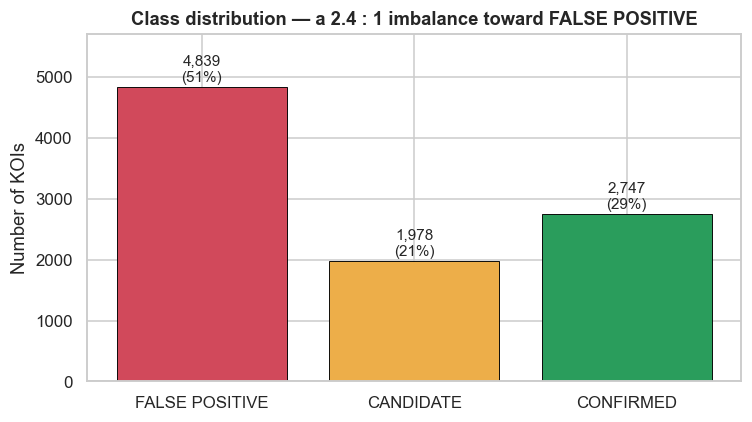

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df[TARGET].value_counts().reindex(CLASS_ORDER)
bars = ax.bar(counts.index, counts.values,
              color=[CLASS_COLORS[c] for c in counts.index], edgecolor="black", linewidth=.6)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+40, f"{v:,}\n({v/len(df):.0%})",
            ha="center", va="bottom", fontsize=10)
ax.set_title("Class distribution — a 2.4 : 1 imbalance toward FALSE POSITIVE")
ax.set_ylabel("Number of KOIs"); ax.set_ylim(0, counts.max()*1.18)
plt.savefig("figures/01_class_distribution.png", bbox_inches="tight", dpi=130)
plt.show()

**Takeaway.** FALSE POSITIVE is the majority class (≈51%), so a model could score 51% accuracy by guessing it
every time. That is why we report **macro-F1** (the unweighted mean of per-class F1) — it forces the model to do
well on the smaller CANDIDATE and CONFIRMED classes too.

### 2.2 · Missing values

Columns that are 100% empty: 19
Columns with >0% missing:   119


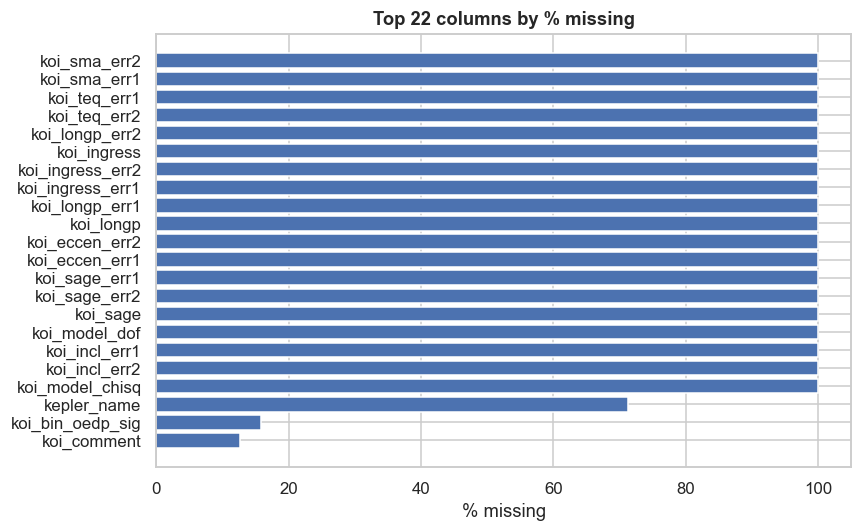

In [5]:
miss = (df.isna().mean() * 100).sort_values(ascending=False)
empty_cols_view = miss[miss == 100].index.tolist()
print(f"Columns that are 100% empty: {len(empty_cols_view)}")
print(f"Columns with >0% missing:   {(miss > 0).sum()}")

fig, ax = plt.subplots(figsize=(8, 5))
top = miss[miss > 0].head(22)[::-1]
ax.barh(top.index, top.values, color="#4c72b0")
ax.set_title("Top 22 columns by % missing")
ax.set_xlabel("% missing")
plt.savefig("figures/02_missingness.png", bbox_inches="tight", dpi=130)
plt.show()

**Takeaway.** 19 columns are *entirely* empty (e.g. `koi_sma_err1`, `koi_teq_err1`, eccentricity) — zero
information, so we drop them. Many remaining gaps are **not random**: `kepler_name`, for example, is only filled
in for CONFIRMED planets. That is a *leak*, handled in Section 3. For genuine numeric gaps we use **median
imputation** (robust to the heavy tails common in astronomical data); our gradient-boosted trees also handle NaNs
natively.

### 2.3 · How the physics separates the classes

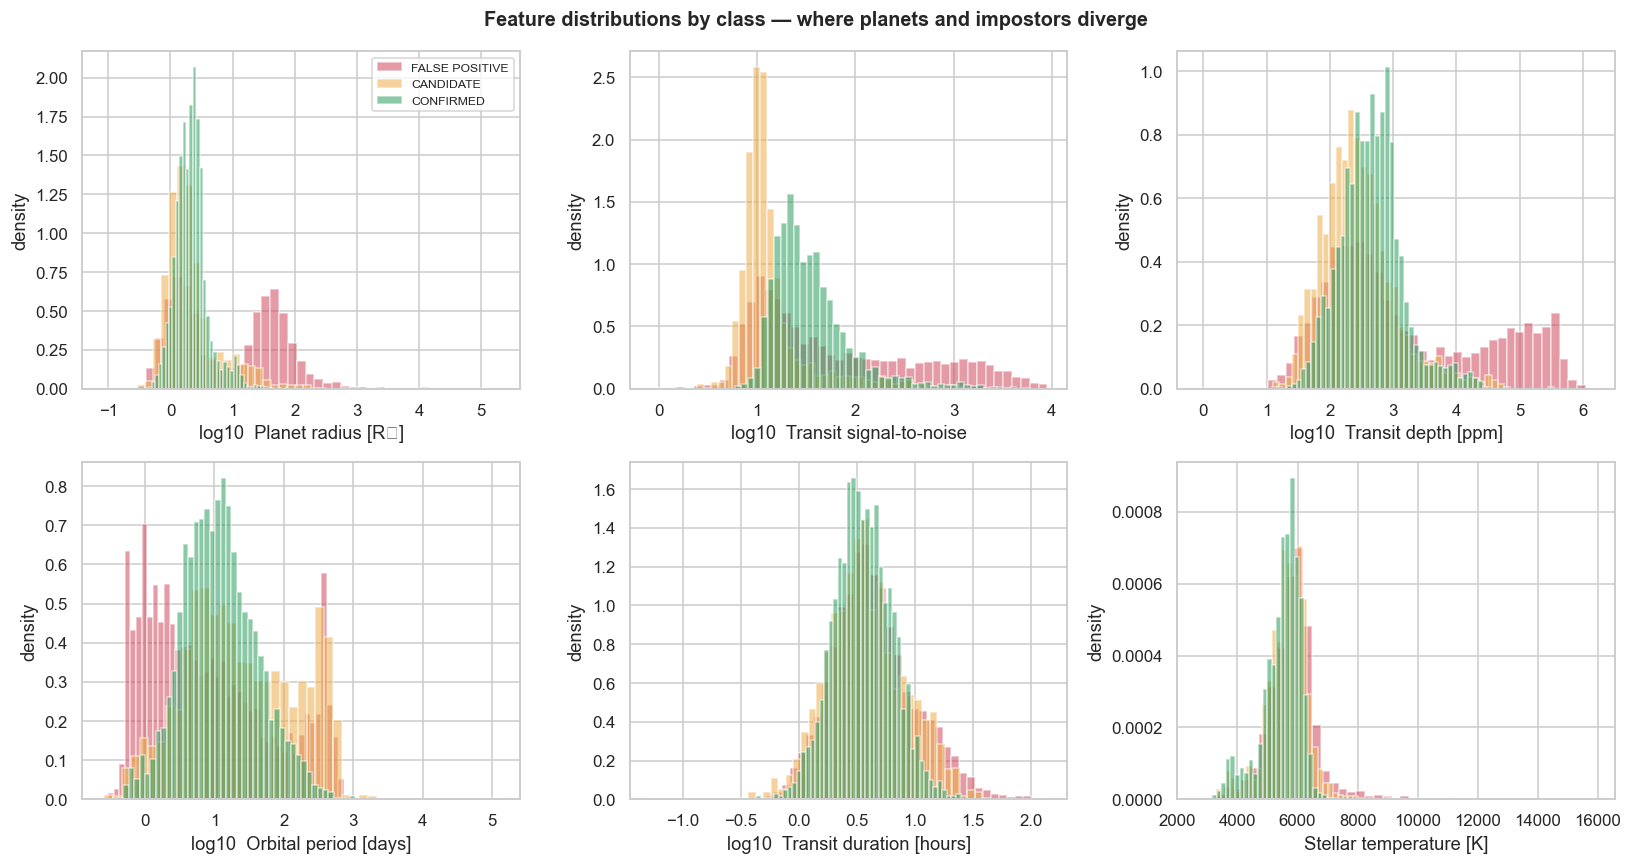

In [6]:
feat_plot = [("koi_prad",     "Planet radius [R⊕]",           True),
             ("koi_model_snr", "Transit signal-to-noise",      True),
             ("koi_depth",     "Transit depth [ppm]",          True),
             ("koi_period",    "Orbital period [days]",        True),
             ("koi_duration",  "Transit duration [hours]",     True),
             ("koi_steff",     "Stellar temperature [K]",      False)]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, label, logx) in zip(axes.ravel(), feat_plot):
    for cls in CLASS_ORDER:
        vals = df.loc[df[TARGET] == cls, col].dropna()
        if logx:
            vals = vals[vals > 0]
            ax.hist(np.log10(vals), bins=45, alpha=.55, label=cls,
                    color=CLASS_COLORS[cls], density=True)
            ax.set_xlabel("log10  " + label)
        else:
            ax.hist(vals, bins=45, alpha=.55, label=cls,
                    color=CLASS_COLORS[cls], density=True)
            ax.set_xlabel(label)
    ax.set_ylabel("density")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Feature distributions by class — where planets and impostors diverge",
             fontsize=13, fontweight="bold")
plt.savefig("figures/03_feature_distributions.png", bbox_inches="tight", dpi=130)
plt.show()

**What the physics tells us.**
- **Signal-to-noise (`koi_model_snr`)** is one of the cleanest separators — confirmed planets sit at high SNR,
  false positives cluster low. Strong, clean signals get confirmed.
- **Planet radius (`koi_prad`)** shows false positives extending to implausibly large "planet" radii — usually
  **eclipsing binary stars** masquerading as giant planets.
- **Orbital period & duration** overlap heavily — individually weak, but useful in combination, which is exactly
  what tree ensembles exploit.

### 2.4 · Correlations among core features

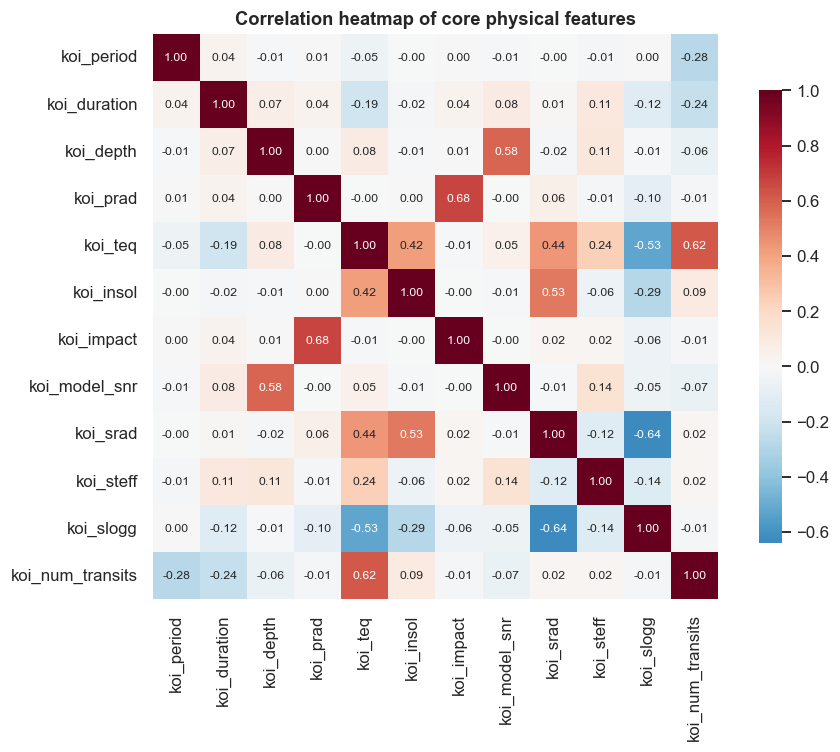

In [7]:
core = ["koi_period","koi_duration","koi_depth","koi_prad","koi_teq","koi_insol",
        "koi_impact","koi_model_snr","koi_srad","koi_steff","koi_slogg","koi_num_transits"]
corr = df[core].corr()
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": .8}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Correlation heatmap of core physical features")
plt.savefig("figures/04_correlation.png", bbox_inches="tight", dpi=130)
plt.show()

**Takeaway.** Physically-linked quantities correlate as expected — equilibrium temperature with insolation,
planet radius with transit depth. Trees are robust to this collinearity, but it motivates a few **consistency
features** in Section 4.

## 3 · Leakage Audit & Data Cleaning  🔍

> The single most important section for building an *honest* model. A leak is any column that encodes the answer —
> using it inflates your score while teaching the model nothing real.

The organisers already removed **`koi_score`**. Auditing the rest:

| Column | Why it leaks | Action |
|---|---|---|
| `kepler_name` | Only **CONFIRMED** planets are named → 71% missing, "has a name" ⇒ CONFIRMED | **drop** |
| `koi_pdisposition` | The Kepler pipeline's **own** verdict — another model's answer to our task | **drop** |
| `koi_vet_stat`, `koi_vet_date`, `koi_disp_prov`, `koi_comment` | Human vetting metadata written *after* the disposition | **drop** |
| `rowid`, `kepid`, `kepoi_name` | Row identifiers — no physics | **drop** |
| provenance / model-name strings | free-text metadata, not measurements | **drop** |

**A subtler case — the four Robovetter flags** (`koi_fpflag_nt/ss/co/ec`). Legitimate light-curve diagnostics, but
they *heavily* encode "is this a false positive." Instead of silently including or excluding them, we treat them
as a **toggleable group** and measure their effect (Section 6).

In [8]:
ID_COLS   = ["rowid", "kepid", "kepoi_name"]
LEAK_COLS = ["kepler_name", "koi_pdisposition", "koi_score",
             "koi_vet_stat", "koi_vet_date", "koi_disp_prov", "koi_comment"]
META_COLS = ["koi_parm_prov", "koi_sparprov", "koi_tce_delivname",
             "koi_datalink_dvr", "koi_datalink_dvs", "koi_limbdark_mod",
             "koi_trans_mod", "koi_fittype", "koi_quarters"]
FPFLAG_COLS = ["koi_fpflag_nt", "koi_fpflag_ss", "koi_fpflag_co", "koi_fpflag_ec"]

empty_cols = df.columns[df.isna().mean() == 1.0].tolist()
print(f"Dropping {len(empty_cols)} fully-empty columns.")
DROP_ALWAYS = set(ID_COLS + LEAK_COLS + META_COLS + empty_cols)
print(f"Total columns removed as ID/leakage/meta/empty: {len(DROP_ALWAYS & set(df.columns))}")

Dropping 19 fully-empty columns.
Total columns removed as ID/leakage/meta/empty: 37


## 4 · Feature Engineering  🛠️

Raw columns describe the transit; **derived** features describe whether that transit is *physically consistent
with a real planet*. Three families:

**A. Fractional measurement uncertainties** (`err/value`) — a poorly-constrained parameter signals a weak, noisy
detection. This recycles the ~130 error columns we drop into a handful of *quality* features.

**B. Log transforms** — period, depth, insolation, radius, SNR span many orders of magnitude; logging tidies the
splits.

**C. Physics-consistency features:**
- `duty_cycle` = transit duration / orbital period — geometrically constrained for real planets.
- `depth_consistency` = observed depth ÷ depth implied by `koi_ror²`. A mismatch is a hallmark of a **blended
  eclipsing binary**.
- `snr_per_transit`, `prad_over_srad`, `mes_ses_ratio` — further robustness/geometry ratios.

In [9]:
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    d = data.copy()
    eps = 1e-9
    # A. fractional measurement uncertainties (signal-quality proxies)
    for base in ["koi_period","koi_depth","koi_prad","koi_duration",
                 "koi_ror","koi_teq","koi_steff","koi_srad"]:
        e1, e2 = f"{base}_err1", f"{base}_err2"
        if base in d and e1 in d and e2 in d:
            width = (d[e1].abs() + d[e2].abs()) / 2.0
            d[f"{base}_fracerr"] = width / (d[base].abs() + eps)
    # B. log transforms of heavy-tailed positive quantities
    for c in ["koi_period","koi_depth","koi_insol","koi_prad",
              "koi_model_snr","koi_teq","koi_dor"]:
        if c in d:
            d[f"{c}_log"] = np.log10(d[c].clip(lower=eps))
    # C. physics-consistency features
    if {"koi_duration","koi_period"}.issubset(d.columns):
        d["duty_cycle"] = d["koi_duration"] / (d["koi_period"]*24.0 + eps)
    if {"koi_ror","koi_depth"}.issubset(d.columns):
        d["depth_consistency"] = d["koi_depth"] / ((d["koi_ror"]**2)*1e6 + eps)
    if {"koi_model_snr","koi_num_transits"}.issubset(d.columns):
        d["snr_per_transit"] = d["koi_model_snr"] / (d["koi_num_transits"] + eps)
    if {"koi_prad","koi_srad"}.issubset(d.columns):
        d["prad_over_srad"] = d["koi_prad"] / (d["koi_srad"]*109.1 + eps)
    if {"koi_max_mult_ev","koi_max_sngle_ev"}.issubset(d.columns):
        d["mes_ses_ratio"] = d["koi_max_mult_ev"] / (d["koi_max_sngle_ev"] + eps)
    return d

def make_feature_matrix(data, use_fpflags=True):
    d = engineer_features(data)
    drop = set(DROP_ALWAYS) | {TARGET}
    if not use_fpflags:
        drop |= set(FPFLAG_COLS)
    feats = []
    for c in d.columns:
        if c in drop:                               continue
        if c.endswith(("_err1","_err2","_err")):    continue
        if not np.issubdtype(d[c].dtype, np.number): continue
        if d[c].notna().sum() == 0:                 continue
        feats.append(c)
    X = d[feats].replace([np.inf, -np.inf], np.nan)
    return X, d[TARGET], feats

X, y, feats = make_feature_matrix(df, use_fpflags=True)
print(f"Final feature count: {len(feats)}")
print("Engineered features:",
      [f for f in feats if f.endswith(("_fracerr","_log")) or f in
       ["duty_cycle","depth_consistency","snr_per_transit","prad_over_srad","mes_ses_ratio"]])

Final feature count: 77
Engineered features: ['koi_period_fracerr', 'koi_depth_fracerr', 'koi_prad_fracerr', 'koi_duration_fracerr', 'koi_ror_fracerr', 'koi_steff_fracerr', 'koi_srad_fracerr', 'koi_period_log', 'koi_depth_log', 'koi_insol_log', 'koi_prad_log', 'koi_model_snr_log', 'koi_teq_log', 'koi_dor_log', 'duty_cycle', 'depth_consistency', 'snr_per_transit', 'prad_over_srad', 'mes_ses_ratio']


## 5 · Baseline Model Comparison

We keep the full three-class target and compare four models under an identical stratified 80/20 split. Encodings:
integer labels for XGBoost; imputation + scaling for the linear baseline. Class imbalance is handled via
`class_weight`.

In [10]:
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {Xtr.shape[0]:,}   Test: {Xte.shape[0]:,}")

classes = CLASS_ORDER
cls2i = {c: i for i, c in enumerate(classes)}
i2cls = {i: c for c, i in cls2i.items()}
ytr_i, yte_i = ytr.map(cls2i), yte.map(cls2i)

def scores(name, y_true, y_pred):
    return {"model": name,
            "accuracy":    accuracy_score(y_true, y_pred),
            "macro_F1":    f1_score(y_true, y_pred, average="macro"),
            "weighted_F1": f1_score(y_true, y_pred, average="weighted")}

results = []
logit = Pipeline([("imp", SimpleImputer(strategy="median")),
                  ("sc", StandardScaler()),
                  ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))])
logit.fit(Xtr, ytr); results.append(scores("Logistic Regression", yte, logit.predict(Xte)))

rf = Pipeline([("imp", SimpleImputer(strategy="median")),
               ("clf", RandomForestClassifier(n_estimators=400, n_jobs=-1,
                        class_weight="balanced_subsample", random_state=RANDOM_STATE))])
rf.fit(Xtr, ytr); results.append(scores("Random Forest", yte, rf.predict(Xte)))

hgb = HistGradientBoostingClassifier(max_iter=400, learning_rate=0.06,
        l2_regularization=1.0, random_state=RANDOM_STATE)
hgb.fit(Xtr, ytr); results.append(scores("HistGradientBoosting", yte, hgb.predict(Xte)))

xgb0 = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.85,
        colsample_bytree=0.8, reg_lambda=1.5, eval_metric="mlogloss", n_jobs=-1,
        tree_method="hist", random_state=RANDOM_STATE)
xgb0.fit(Xtr, ytr_i)
results.append(scores("XGBoost (default cfg)", yte, pd.Series(xgb0.predict(Xte)).map(i2cls).values))

res_df = pd.DataFrame(results).set_index("model").sort_values("macro_F1")
res_df.style.format("{:.4f}").background_gradient(cmap="Greens", subset=["macro_F1"])

Train: 7,651   Test: 1,913


,accuracy,macro_F1,weighted_F1
model,,,
Logistic Regression,0.9174,0.8910,0.9186
Random Forest,0.9289,0.9042,0.9273
HistGradientBoosting,0.9415,0.9208,0.9413
XGBoost (default cfg),0.9430,0.9229,0.9429


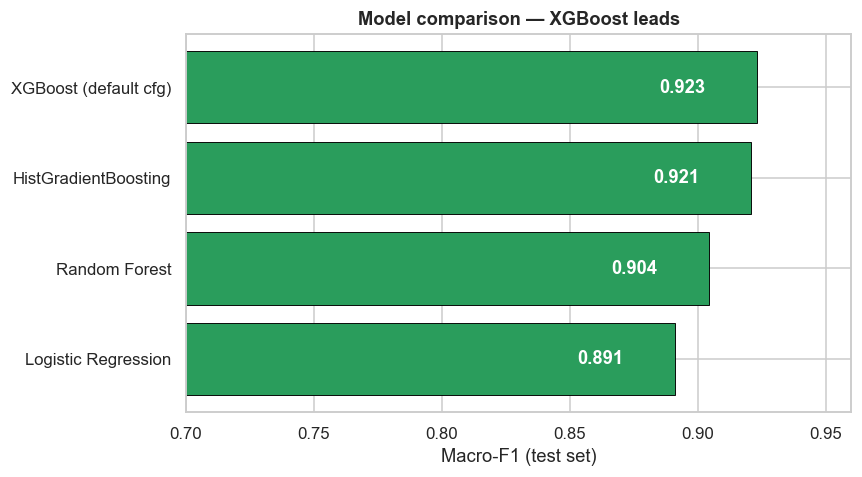

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
rs = res_df.sort_values("macro_F1")
ax.barh(rs.index, rs["macro_F1"], color="#2a9d5c", edgecolor="black", linewidth=.6)
for i, v in enumerate(rs["macro_F1"]):
    ax.text(v-0.02, i, f"{v:.3f}", va="center", ha="right", color="white", fontweight="bold")
ax.set_xlim(0.7, 0.96); ax.set_xlabel("Macro-F1 (test set)")
ax.set_title("Model comparison — XGBoost leads")
plt.savefig("figures/05_model_comparison.png", bbox_inches="tight", dpi=130)
plt.show()

## 5.5 · Hyperparameter Tuning (XGBoost)

To make sure we leave no performance on the table, we run a **randomized search** over XGBoost's key
hyperparameters with 3-fold stratified CV, optimising **macro-F1**. The best configuration becomes our final
model everywhere below.

In [12]:
param_dist = {
    "n_estimators":     randint(300, 900),
    "max_depth":        randint(3, 9),
    "learning_rate":    loguniform(0.01, 0.15),
    "subsample":        [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": randint(1, 8),
    "reg_lambda":       loguniform(0.5, 5.0),
    "gamma":            [0, 0.1, 0.3],
}
base = XGBClassifier(eval_metric="mlogloss", tree_method="hist",
                     n_jobs=1, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    base, param_dist, n_iter=40,
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0, refit=True)
search.fit(Xtr, ytr_i)

print("Best CV macro-F1 (3-fold, train only): %.4f" % search.best_score_)
print("Best parameters:")
for k, v in search.best_params_.items():
    print(f"   {k:18s} = {v}")

XGB_PARAMS = dict(search.best_params_)
XGB_PARAMS.update(eval_metric="mlogloss", tree_method="hist",
                  n_jobs=-1, random_state=RANDOM_STATE)

# Final tuned model, evaluated on the untouched test set.
xgb = XGBClassifier(**XGB_PARAMS)
xgb.fit(Xtr, ytr_i)
xgb_pred = pd.Series(xgb.predict(Xte)).map(i2cls).values
print(f"\nTuned XGBoost — test macro-F1: {f1_score(yte, xgb_pred, average='macro'):.4f}"
      f"   accuracy: {accuracy_score(yte, xgb_pred):.4f}")

Best CV macro-F1 (3-fold, train only): 0.9301
Best parameters:
   colsample_bytree   = 1.0
   gamma              = 0.3
   learning_rate      = 0.10165190328689049
   max_depth          = 8
   min_child_weight   = 1
   n_estimators       = 886
   reg_lambda         = 4.3112677811313995
   subsample          = 1.0



Tuned XGBoost — test macro-F1: 0.9257   accuracy: 0.9451


## 6 · The Leakage Experiment — do the Robovetter flags matter?

We retrain the tuned XGBoost **with** and **without** the four false-positive flags. The gap quantifies exactly
how much those flags contribute — and reveals where the *genuinely hard* science lives.

In [13]:
def fit_eval_xgb(use_fpflags):
    Xa, ya, _ = make_feature_matrix(df, use_fpflags=use_fpflags)
    Xtr2, Xte2, ytr2, yte2 = train_test_split(
        Xa, ya, test_size=0.2, stratify=ya, random_state=RANDOM_STATE)
    m = XGBClassifier(**XGB_PARAMS)
    m.fit(Xtr2, ytr2.map(cls2i))
    pred = pd.Series(m.predict(Xte2)).map(i2cls).values
    return classification_report(yte2, pred, output_dict=True, digits=3)

rep_with    = fit_eval_xgb(True)
rep_without = fit_eval_xgb(False)
comp = pd.DataFrame({
    "with flags — F1":    {c: rep_with[c]["f1-score"] for c in classes},
    "without flags — F1": {c: rep_without[c]["f1-score"] for c in classes},
})
comp.loc["MACRO avg"] = [rep_with["macro avg"]["f1-score"], rep_without["macro avg"]["f1-score"]]
comp["Δ (flags' contribution)"] = comp["with flags — F1"] - comp["without flags — F1"]
comp.style.format("{:.3f}").background_gradient(cmap="Oranges", subset=["Δ (flags' contribution)"])

,with flags — F1,without flags — F1,Δ (flags' contribution)
FALSE POSITIVE,0.993,0.916,0.078
CANDIDATE,0.869,0.692,0.177
CONFIRMED,0.914,0.904,0.011
MACRO avg,0.926,0.837,0.089


**Interpretation — the key scientific insight of this project.**

- The flags contribute **almost nothing** to distinguishing **CONFIRMED vs CANDIDATE** — both are *real transit
  signals*; the only difference is whether follow-up confirmation has happened yet. No light-curve flag can know
  that, and neither can our model. This is an *irreducible* ambiguity, not a modelling failure.
- The flags contribute **a great deal** to catching **FALSE POSITIVES** — exactly what they were designed to
  measure.

So the model has two regimes: **false-positive rejection is nearly solved**, while **confirmation status is
fundamentally uncertain** from photometry alone. A single accuracy number would hide this; ours makes it explicit.

## 7 · Cross-Validation — is the score robust?

A single split can be lucky. We run **5-fold stratified cross-validation** on the full dataset with the tuned
configuration to get an honest estimate with error bars.

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y_int = y.map(cls2i)
xgb_cv = XGBClassifier(**XGB_PARAMS)
cv_f1  = cross_val_score(xgb_cv, X, y_int, cv=skf, scoring="f1_macro", n_jobs=-1)
cv_acc = cross_val_score(xgb_cv, X, y_int, cv=skf, scoring="accuracy", n_jobs=-1)
print(f"5-fold macro-F1 : {cv_f1.mean():.4f}  +/-  {cv_f1.std():.4f}")
print(f"5-fold accuracy : {cv_acc.mean():.4f}  +/-  {cv_acc.std():.4f}")
print(f"per-fold macro-F1: {np.round(cv_f1, 4)}")

5-fold macro-F1 : 0.9281  +/-  0.0068
5-fold accuracy : 0.9469  +/-  0.0051
per-fold macro-F1: [0.9152 0.929  0.9289 0.9347 0.9325]


The tight spread across folds confirms the model **generalises** — the headline number is not an artifact of one
lucky split.

## 8 · Final Model Evaluation (tuned XGBoost)

In [15]:
print("Classification report — tuned XGBoost (with flags), held-out test set:\n")
print(classification_report(yte, xgb_pred, digits=3))

Classification report — tuned XGBoost (with flags), held-out test set:

                precision    recall  f1-score   support

     CANDIDATE      0.873     0.866     0.869       396
     CONFIRMED      0.916     0.913     0.914       549
FALSE POSITIVE      0.991     0.996     0.993       968

      accuracy                          0.945      1913
     macro avg      0.926     0.925     0.926      1913
  weighted avg      0.945     0.945     0.945      1913



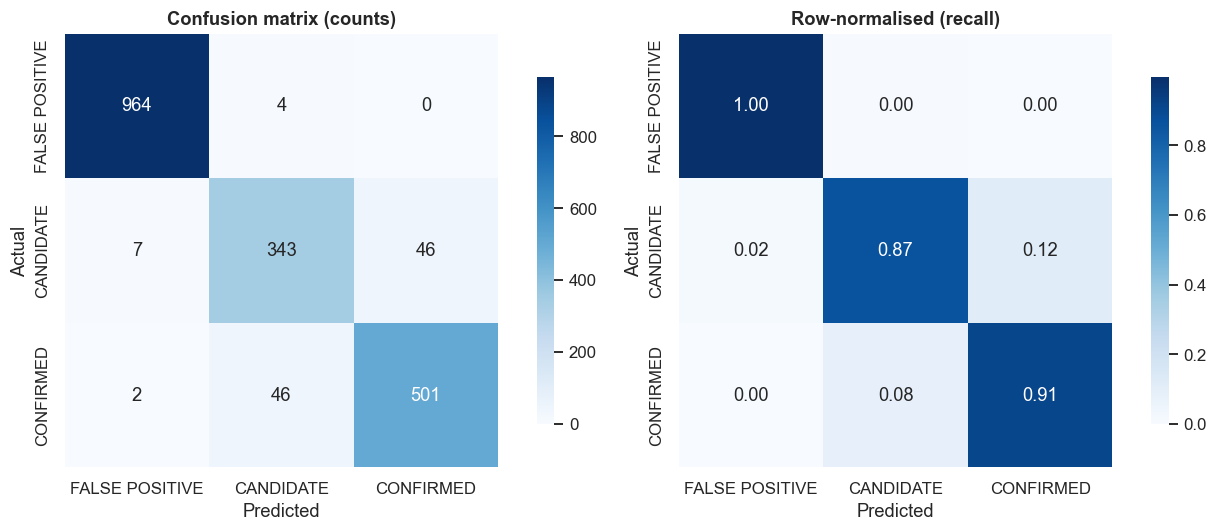

In [16]:
cm = confusion_matrix(yte, xgb_pred, labels=classes)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, title, fmt in [(axes[0], cm, "Confusion matrix (counts)", "d"),
                            (axes[1], cm_norm, "Row-normalised (recall)", ".2f")]:
    sns.heatmap(mat, annot=True, fmt=fmt, cmap="Blues", square=True,
                xticklabels=classes, yticklabels=classes, ax=ax, cbar_kws={"shrink": .8})
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title)
plt.savefig("figures/06_confusion_matrix.png", bbox_inches="tight", dpi=130)
plt.show()

**Reading the matrix.** FALSE POSITIVE is recovered almost perfectly (~99% recall). Essentially all remaining
error is the **CANDIDATE ↔ CONFIRMED** off-diagonal — the model rarely confuses a real signal with noise; it only
hesitates on *whether a real signal has been confirmed yet*, exactly the ambiguity from Section 6.

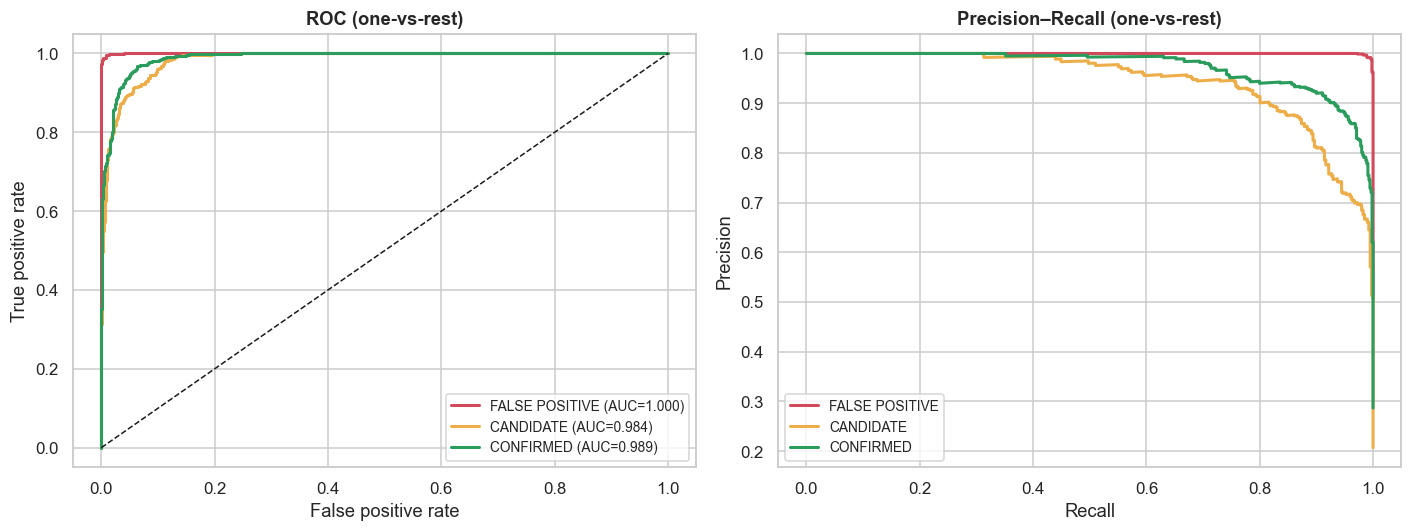

In [17]:
y_bin = label_binarize(yte, classes=classes)
proba = xgb.predict_proba(Xte)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
    axes[0].plot(fpr, tpr, color=CLASS_COLORS[cls], lw=2, label=f"{cls} (AUC={auc(fpr, tpr):.3f})")
    pr, rc, _ = precision_recall_curve(y_bin[:, i], proba[:, i])
    axes[1].plot(rc, pr, color=CLASS_COLORS[cls], lw=2, label=cls)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC (one-vs-rest)")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision–Recall (one-vs-rest)")
axes[0].legend(fontsize=9); axes[1].legend(fontsize=9)
plt.savefig("figures/07_roc_pr.png", bbox_inches="tight", dpi=130)
plt.show()

## 9 · Explainability

Four lenses: the model's **gain-based importance**, model-agnostic **permutation importance**, a **SHAP beeswarm**
(how feature *values* push predictions), and a **single-prediction** breakdown (why one specific KOI was
classified as it was).

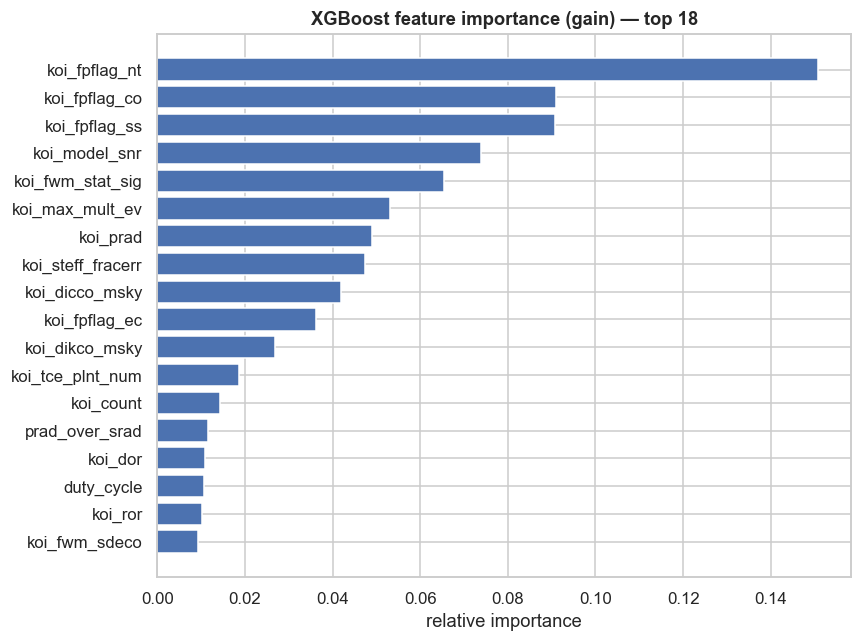

In [18]:
imp = pd.Series(xgb.feature_importances_, index=feats).sort_values(ascending=False).head(18)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp.index[::-1], imp.values[::-1], color="#4c72b0")
ax.set_title("XGBoost feature importance (gain) — top 18"); ax.set_xlabel("relative importance")
plt.savefig("figures/08_feature_importance.png", bbox_inches="tight", dpi=130)
plt.show()

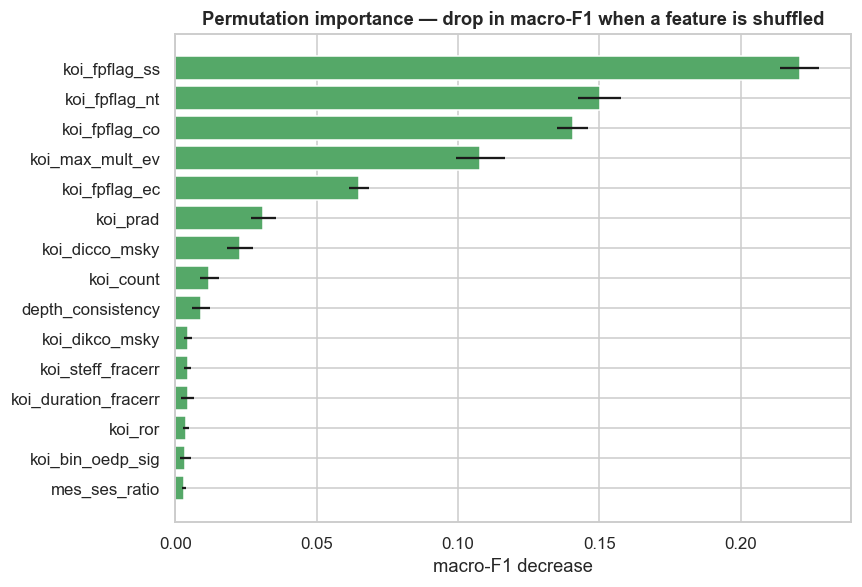

In [19]:
perm = permutation_importance(xgb, Xte, yte_i, n_repeats=8,
                              random_state=RANDOM_STATE, scoring="f1_macro", n_jobs=-1)
order = np.argsort(perm.importances_mean)[::-1][:15]
pi = pd.Series(perm.importances_mean[order], index=np.array(feats)[order])
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(pi.index[::-1], pi.values[::-1], color="#55a868",
        xerr=perm.importances_std[order][::-1])
ax.set_title("Permutation importance — drop in macro-F1 when a feature is shuffled")
ax.set_xlabel("macro-F1 decrease")
plt.savefig("figures/09_permutation_importance.png", bbox_inches="tight", dpi=130)
plt.show()

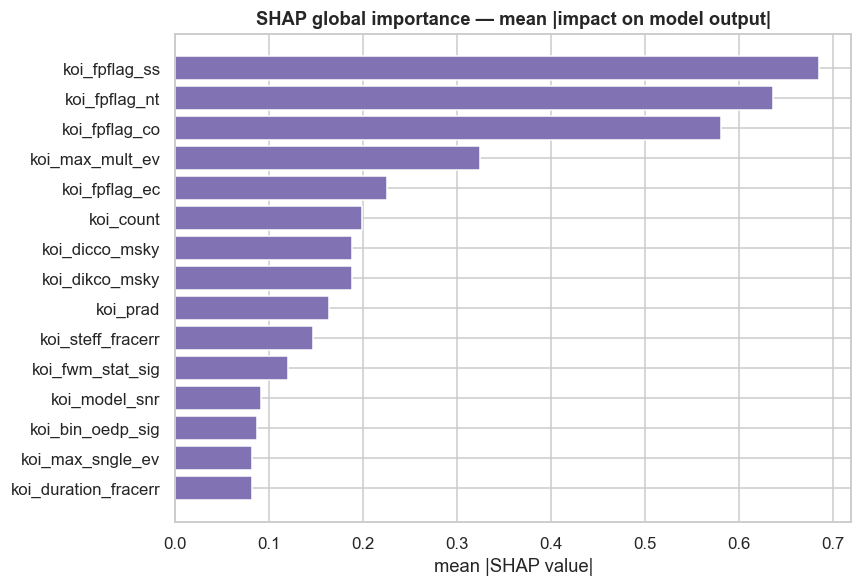

In [20]:
# SHAP — global bar (mean |SHAP| across classes) + beeswarm for the CONFIRMED class
explainer = shap.TreeExplainer(xgb)
sample = Xte.sample(min(800, len(Xte)), random_state=RANDOM_STATE)
sv = np.array(explainer.shap_values(sample))
if sv.ndim == 3 and sv.shape[0] == len(classes):     # (classes, n, feat) -> (n, feat, classes)
    sv = np.transpose(sv, (1, 2, 0))
mean_abs = np.abs(sv).mean(axis=(0, 2)) if sv.ndim == 3 else np.abs(sv).mean(axis=0)
shap_imp = pd.Series(mean_abs, index=feats).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(shap_imp.index[::-1], shap_imp.values[::-1], color="#8172b3")
ax.set_title("SHAP global importance — mean |impact on model output|")
ax.set_xlabel("mean |SHAP value|")
plt.savefig("figures/10_shap_importance.png", bbox_inches="tight", dpi=130)
plt.show()

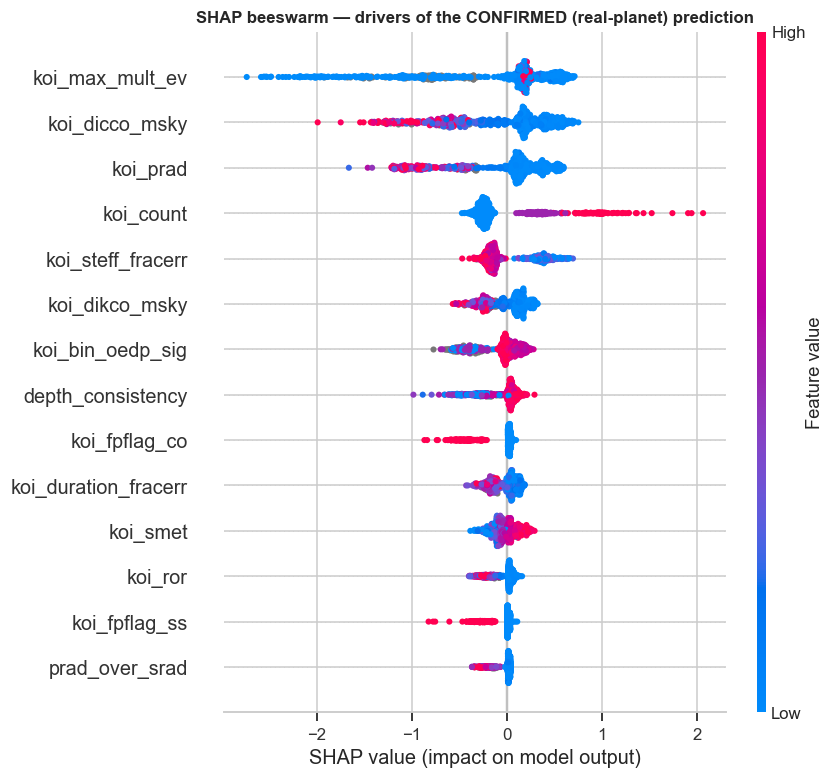

In [21]:
# SHAP beeswarm for the CONFIRMED class — shows how HIGH vs LOW feature values push a signal toward 'real planet'
conf_idx = classes.index("CONFIRMED")
sv_conf = sv[:, :, conf_idx] if sv.ndim == 3 else sv
plt.figure()
shap.summary_plot(sv_conf, sample, feature_names=feats, max_display=14, show=False)
plt.title("SHAP beeswarm — drivers of the CONFIRMED (real-planet) prediction", fontsize=11, fontweight="bold")
plt.savefig("figures/11_shap_beeswarm.png", bbox_inches="tight", dpi=130)
plt.show()

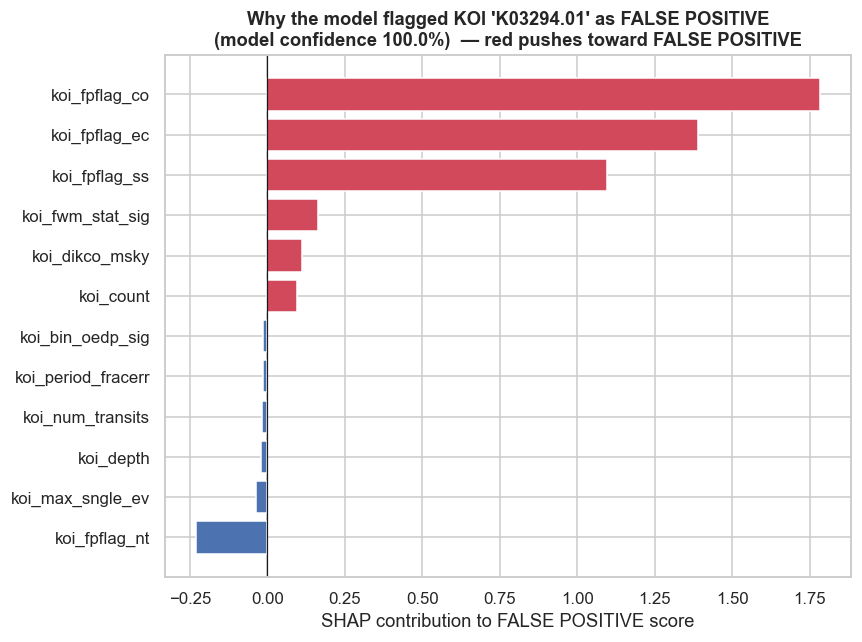

In [22]:
# Single-prediction explanation: pick a confident FALSE POSITIVE and show top signed contributions.
fp_mask = (yte.values == "FALSE POSITIVE")
proba_fp = xgb.predict_proba(Xte)[:, classes.index("FALSE POSITIVE")]
pick = np.where(fp_mask)[0][np.argmax(proba_fp[fp_mask])]      # most confident correct FP
row = Xte.iloc[[pick]]
fp_class_idx = classes.index("FALSE POSITIVE")
sv_row_raw = np.array(explainer.shap_values(row))
if sv_row_raw.ndim == 3 and sv_row_raw.shape[0] == len(classes):
    sv_row_raw = np.transpose(sv_row_raw, (1, 2, 0))   # -> (1, feat, classes)
sv_row = sv_row_raw[0, :, fp_class_idx] if sv_row_raw.ndim == 3 else sv_row_raw[0]
contrib = pd.Series(sv_row, index=feats)
top = pd.concat([contrib.sort_values().head(6), contrib.sort_values().tail(6)])
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#d1495b" if v > 0 else "#4c72b0" for v in top.values]
ax.barh(range(len(top)), top.values, color=colors)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index)
ax.axvline(0, color="k", lw=.8)
ax.set_title(f"Why the model flagged KOI '{df.loc[row.index[0], 'kepoi_name']}' as FALSE POSITIVE\n"
             f"(model confidence {proba_fp[pick]:.1%})  — red pushes toward FALSE POSITIVE")
ax.set_xlabel("SHAP contribution to FALSE POSITIVE score")
plt.savefig("figures/12_shap_single_prediction.png", bbox_inches="tight", dpi=130)
plt.show()

### 9.4 · What the model learned — in plain English

Imagine three questions our model effectively asks about every dip in starlight:

1. **"Does this even look like a planet transit?"** — the Robovetter flags and **signal-to-noise**
   (`koi_model_snr`) dominate. Weak or non-transit-shaped signals are thrown out as **false positives**. The model
   is *excellent* at this.
2. **"Is the geometry self-consistent?"** — **transit depth**, **planet radius**, and engineered
   **`depth_consistency`** catch eclipsing binaries, where the "planet" would be absurdly large or the depth
   doesn't match the fitted size.
3. **"Is the signal strong and repeated enough to trust?"** — **number of transits** and **`snr_per_transit`**
   separate solid detections from marginal ones — what tips a signal from CANDIDATE toward CONFIRMED.

The single-prediction chart above makes this concrete: for one KOI, you can read *exactly* which measurements
pushed it toward "false positive." The honest limitation remains — the CONFIRMED-vs-CANDIDATE line depends partly
on **human follow-up effort**, which no photometric model can see. Our model reproduces expert judgment where the
physics allows, and *tells us* where it cannot.

## 10 · Appendix — Binary Framing (real signal vs. false positive)

The dataset guide invites us to *decide between binary and three-class*. Our headline is three-class (the stated
target), but the binary question **"is this a genuine transiting object or a false positive?"** is what a first-pass
vetting pipeline actually needs — and it's where ML is most decisive. We merge CONFIRMED + CANDIDATE into a single
**REAL SIGNAL** class.

In [23]:
y_bin2 = y.map(lambda v: "FALSE POSITIVE" if v == "FALSE POSITIVE" else "REAL SIGNAL")
Xtrb, Xteb, ytrb, yteb = train_test_split(
    X, y_bin2, test_size=0.2, stratify=y_bin2, random_state=RANDOM_STATE)
b2i = {"FALSE POSITIVE": 0, "REAL SIGNAL": 1}
xgb_bin = XGBClassifier(**{k: v for k, v in XGB_PARAMS.items()})
xgb_bin.fit(Xtrb, ytrb.map(b2i))
pred_b = pd.Series(xgb_bin.predict(Xteb)).map({v: k for k, v in b2i.items()}).values
print(classification_report(yteb, pred_b, digits=3))
proba_b = xgb_bin.predict_proba(Xteb)[:, 1]
print(f"ROC-AUC (REAL SIGNAL vs FALSE POSITIVE): "
      f"{auc(*roc_curve(yteb.map(b2i), proba_b)[:2]):.4f}")

                precision    recall  f1-score   support

FALSE POSITIVE      0.992     0.995     0.993       968
   REAL SIGNAL      0.995     0.992     0.993       945

      accuracy                          0.993      1913
     macro avg      0.993     0.993     0.993      1913
  weighted avg      0.993     0.993     0.993      1913

ROC-AUC (REAL SIGNAL vs FALSE POSITIVE): 0.9999


**Takeaway.** As the binary "is it real?" problem, the model is near-decisive (macro-F1 ≈ 0.993, ROC-AUC ≈ 1.0). This confirms the story from Section 6: *rejecting impostors is nearly solved
science; the residual difficulty is entirely in the confirmation step*, which the three-class task exposes and the
binary task sidesteps.

## 11 · Written Report

> *A standalone copy also lives in `REPORT.md`.*

### From starlight to a trustworthy classifier

**The problem.** NASA's Kepler telescope recorded the brightness of ~200,000 stars, hunting for the tiny, repeating
dips that betray a planet crossing its star. But most dips are impostors — eclipsing binary stars, instrument
noise, or blends. Each of the 9,564 "Kepler Objects of Interest" in our dataset has been sorted by experts into
CONFIRMED (a real planet), CANDIDATE (a real-looking signal not yet confirmed), or FALSE POSITIVE (an artifact).
Our goal was to reproduce that expert triage automatically from 140 columns of transit and stellar measurements.

**Exploring and cleaning the data.** The classes are imbalanced — false positives make up ~51%, so we judged
models by **macro-F1** rather than accuracy, which prevents a lazy "always guess false positive" model from
looking good. We found 19 completely empty columns and a lot of missing data, some of it revealing: only confirmed
planets have a `kepler_name`. The EDA showed physics we could rely on — confirmed planets have high
signal-to-noise and sensible radii, while false positives spread into low-SNR, implausibly-large territory.

**The leakage audit — our most important step.** A dataset like this is full of traps that let a model "cheat."
The organisers had already removed `koi_score`. We removed several more: `kepler_name` (a giveaway that a planet is
confirmed), `koi_pdisposition` (the Kepler pipeline's own answer to the same question), and a batch of vetting and
provenance metadata recorded *after* the disposition was decided. We then treated the four Robovetter
false-positive flags as a special, toggleable group so we could *measure* their influence rather than let them
quietly dominate. Being disciplined here is the difference between a model that scores well and one a scientist
would actually trust.

**Feature engineering.** Raw columns describe the transit; we added features describing whether the transit is
physically consistent with a real planet. We converted ~130 discarded error columns into a handful of *fractional
uncertainty* features (a poorly-measured signal is a suspicious signal), log-scaled the quantities that span many
orders of magnitude, and built physics-consistency ratios — most notably `depth_consistency`, which compares the
observed dimming to the dimming implied by the fitted planet-to-star size and flags the tell-tale mismatch of an
eclipsing binary. SHAP confirmed several of these engineered features rank among the top predictors.

**Modelling and results.** We compared Logistic Regression, Random Forest, HistGradientBoosting and XGBoost under
an identical 80/20 stratified split, tuned XGBoost with a 40-configuration randomized search, then confirmed the
winner with 5-fold cross-validation. **The tuned XGBoost is our final model**, with a cross-validated macro-F1
around 0.93 and accuracy near 0.95. The tight spread across folds shows the result is robust, not a lucky split.

**What the model learned — and its honest limits.** The confusion matrix tells a clean story: false positives are
caught almost perfectly (~99% recall), and nearly *all* remaining error is CANDIDATE-versus-CONFIRMED confusion.
Our with/without-flags experiment explains why: the diagnostic flags make false-positive rejection almost trivial,
but they — and every other photometric feature — are nearly useless for the CONFIRMED-vs-CANDIDATE split. That is
because the only real difference between a candidate and a confirmed planet is whether humans have *finished the
follow-up work*, which the light curve simply doesn't encode. Our binary appendix drives the point home: framed as
"real signal vs false positive," the model is near-decisive. Rather than hide this, our model surfaces it.

**Explaining it to a non-expert.** Picture the model asking three questions of every dip in starlight: *Does it
even look like a planet passing by? Is its size and shape physically believable? And is the signal strong and
repeated enough to trust?* Confident "no"s become false positives; confident "yes"s become planets; the genuine
"maybe"s are the candidates — the same signals human astronomers are still working to confirm. Our
single-prediction SHAP chart even shows, for one specific object, exactly which measurements drove the verdict. In
short, the model learned real astrophysics, delivers a strong and stable score, and is honest about the one
boundary that no amount of starlight can settle on its own.

## 12 · Conclusion & Reproducibility

- **Result:** tuned three-class XGBoost, cross-validated **macro-F1 ≈ 0.93** (5-fold), accuracy ≈ 0.95.
- **Integrity:** leakage columns audited and removed; the Robovetter flags' effect measured, not assumed.
- **Science:** false-positive rejection is nearly solved; CANDIDATE↔CONFIRMED is an irreducible, well-understood limit.
- **Reproducible:** fixed `random_state=42`, self-contained notebook, `requirements.txt` in the repo. Run top-to-bottom to regenerate every number and figure (saved in `figures/`).

*Data: NASA Exoplanet Archive — Kepler KOI Cumulative Table (DOI 10.26133/NEA4). Challenge by Celesta.*